## Consuming data using Kafka and Visualise (20%)
In this task, we will implement an Apache Kafka consumer to consume the data from Part 2.  
  
Important:   
-	In this part, Kafka consumers are used to consume the streaming data published from task streaming and prediction.  

In [1]:
# Import Library
# Spark Configuration
from pyspark import SparkConf
from pyspark.sql import SparkSession

# Kafka Consumer
from kafka3 import KafkaConsumer

# Data Manipulation
import pandas as pd
import threading, json, time, signal
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
from io import StringIO

***Spark Session***

In [2]:
# local[*]: run Spark in local mode with working processors as logical cores on your machine
master = "local[4]"

# The `appName` field is a name to be shown on the Spark cluster UI page
app_name = "Assignment-2B"

# SparkSession Setup
spark = (
    SparkSession.builder
        .master(master)
        .appName(app_name)
        
        # Add Kafka package
        .config("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.0")
        
        # Set timezone for event-time handling
        .config("spark.sql.session.timeZone", "Australia/Melbourne")
        
        # Set checkpoint directory
        .config("spark.sql.streaming.checkpointLocation", "file:///tmp/spark-checkpoint")
        .getOrCreate()
)

# Spark Logging
sc = spark.sparkContext
sc.setLogLevel('ERROR')

***Configurations***

In [3]:
# Kafka Producer
hostip = "kafka"

# Kafka topics
predictions_topic = "predictions5s"
energy_agg_topic = "energyagg7s"
daily_energy_topic = "dailyenergy14s"

***Kafka Consumers***

***6a***

In [4]:
# 6a
consumer_pred   = KafkaConsumer(
    predictions_topic,
    bootstrap_servers=f"{hostip}:9092",
    group_id="a2b-prediction-6a",
    auto_offset_reset="earliest",
    enable_auto_commit=True,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
)

In [13]:
# Read Test
while True:
    raw = consumer_pred.poll(timeout_ms=2000, max_records=100)
    n = sum(len(v) for v in raw.values())
    print("got", n, "msgs")
    
    for tp, msgs in raw.items():
        for m in msgs[:3]:
            print(m.value)  
    if n > 0:
        break

got 100 msgs
{'gbt_prediction': 1284.155421850486, 'event_time': '2025-10-29T23:00:00.000+11:00', 'site_id': 0, 'building_id': 11, 'date': '2022-04-06', 'interval': '0:00-5:59'}
{'gbt_prediction': 450.97962774823606, 'event_time': '2025-10-29T23:00:00.000+11:00', 'site_id': 0, 'building_id': 68, 'date': '2022-04-04', 'interval': '12:00-17:59'}
{'gbt_prediction': 1397.4181754689505, 'event_time': '2025-10-29T23:00:00.000+11:00', 'site_id': 0, 'building_id': 11, 'date': '2022-04-03', 'interval': '18:00-23:59'}


***6b***

In [5]:
# 6b
consumer_agg = KafkaConsumer(
    energy_agg_topic,
    bootstrap_servers=f"{hostip}:9092",
    group_id="a2b-energy-6b",
    auto_offset_reset="earliest",
    enable_auto_commit=True,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
)

In [15]:
# Read Test
while True:
    raw = consumer_agg.poll(timeout_ms=2000, max_records=100)
    n = sum(len(v) for v in raw.values())
    print("got", n, "msgs")
    
    for tp, msgs in raw.items():
        for m in msgs[:3]:
            print(m.value)  
    if n > 0:
        break

got 100 msgs
{'total_predicted_energy': 84.84411543447696, 'total_actual_energy': 0.0, 'site_id': 0, 'building_id': 99, 'date': '2022-01-14', 'interval': '12:00-17:59'}
{'total_predicted_energy': 3640.168121653743, 'total_actual_energy': 0.0, 'site_id': 0, 'building_id': 15, 'date': '2022-01-13', 'interval': '0:00-5:59'}
{'total_predicted_energy': 174.1074730647681, 'total_actual_energy': 0.0, 'site_id': 0, 'building_id': 53, 'date': '2022-01-13', 'interval': '18:00-23:59'}


***6c***

In [6]:
# 6c
consumer_daily  = KafkaConsumer(
    daily_energy_topic,
    bootstrap_servers=f"{hostip}:9092",
    group_id="a2b-daily-6c",
    auto_offset_reset="earliest",
    enable_auto_commit=True,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
) 

In [17]:
# Read Test
while True:
    raw = consumer_daily.poll(timeout_ms=2000, max_records=100)
    n = sum(len(v) for v in raw.values())
    print("got", n, "msgs")
    
    for tp, msgs in raw.items():
        for m in msgs[:3]:
            print(m.value)  
    if n > 0:
        break

got 0 msgs
got 3 msgs
{'predicted_daily_energy': 710673.5917251728, 'actual_daily_energy': 83.67999999999999, 'site_id': 0, 'date': '2022-02-20'}
{'predicted_daily_energy': 348434.98665082105, 'actual_daily_energy': 181.22, 'site_id': 0, 'date': '2022-02-21'}
{'predicted_daily_energy': 1135922.7615396508, 'actual_daily_energy': 959.37, 'site_id': 0, 'date': '2022-02-19'}


In [18]:
print(consumer_pred.subscription())
print(consumer_agg.subscription())
print(consumer_daily.subscription())

{'predictions5s'}
{'energyagg7s'}
{'dailyenergy14s'}


### 1.	Load the new meters CSV file into a data frame.

In [7]:
from pyspark.sql.types import (
    StructType, StructField, FloatType, 
    StringType, IntegerType, TimestampType,
    DoubleType
)

# Meters Schema
meters_schema = StructType([
    StructField("building_id",        IntegerType(),  False),
    StructField("meter_type",         StringType(),   True),
    StructField("ts",                 TimestampType(),True),
    StructField("value",              FloatType(),    True),
    StructField("row_id",             IntegerType(),  False),
])

In [8]:
meters_df = (
    spark.read
         .option("header", "true")
         .schema(meters_schema)
         .option("timestampFormat", "yyyy-MM-dd HH:mm:ss[.SSS]")
         .csv("new_meters.csv")
)

### 2.	Plot two diagrams to show data from 6b and 6c. You are free to choose the type of plot.

***6b. Predicted vs Actual 6h Energy***

Streaming 6b data from Kafka (energyagg7s)... (Ctrl+C to stop)



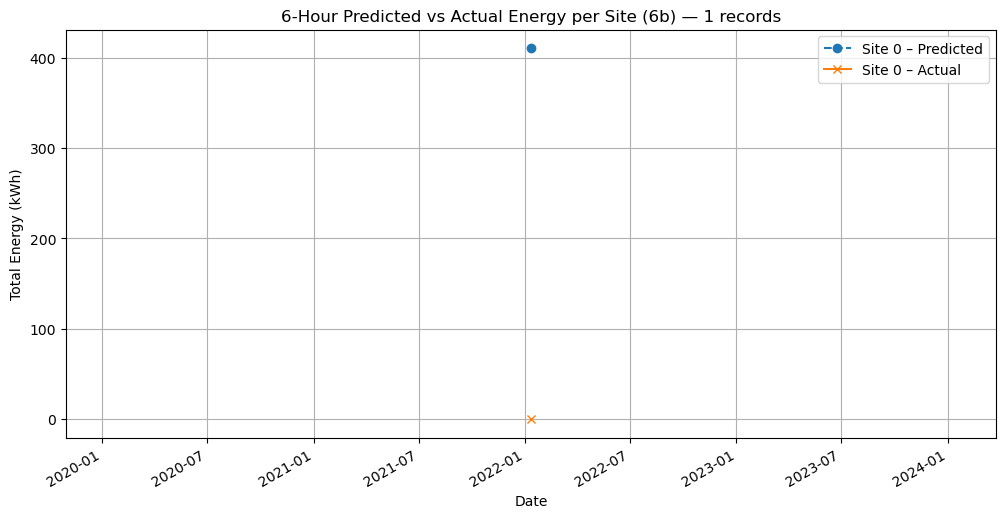


Stopped streaming.


In [16]:
# Initialise Plot
running = True
plt.ion()
fig, ax = plt.subplots(figsize=(12, 6))
records_energy = []
seen_keys = set()

print("Streaming 6b data from Kafka (energyagg7s)... (Ctrl+C to stop)\n")

try:
    while running:
        raw_msgs = consumer_agg.poll(timeout_ms=1000)
        for tp, msgs in raw_msgs.items():
            for msg in msgs:
                data = msg.value
                key = (data["site_id"], data["building_id"], data["date"], data["interval"])
                if key not in seen_keys:
                    records_energy.append(data)
                    seen_keys.add(key)

                    # Convert to DataFrame
                    df = pd.DataFrame(records_energy)
                    df["date"] = pd.to_datetime(df["date"])

                    # Clear previous plot
                    ax.clear()

                    # Plot for each site_id
                    for sid in df["site_id"].unique():
                        sdf = df[df["site_id"] == sid].sort_values(["date", "interval"])

                        ax.plot(
                            sdf["date"],
                            sdf["total_predicted_energy"],
                            label=f"Site {sid} – Predicted",
                            marker="o",
                            linestyle="--",
                        )

                        ax.plot(
                            sdf["date"],
                            sdf["total_actual_energy"],
                            label=f"Site {sid} – Actual",
                            marker="x",
                            linestyle="-",
                        )

                    ax.set_title(
                        f"6‑Hour Predicted vs Actual Energy per Site (6b) — {len(records_energy)} records"
                    )
                    ax.set_xlabel("Date")
                    ax.set_ylabel("Total Energy (kWh)")
                    ax.grid(True)
                    ax.legend()
                    fig.autofmt_xdate()
                    plt.pause(0.5)
                    time.sleep(1)  # <-- slow down so plot updates smoothly
except KeyboardInterrupt:
    print("\nStopped streaming.")
finally:
    plt.ioff()
    plt.show()

This real-time line chart visualizes 6-hour aggregated energy consumption and prediction data streamed from Kafka. A line graph was chosen for its effectiveness in showing temporal trends, making it easy to compare predicted and actual energy usage over time.  
  
Each site’s data is plotted using distinct markers and line styles—circles with dashed lines for predictions, and crosses with solid lines for actual values—to clearly differentiate them while maintaining visual cohesion. The use of `ax.clear()` and `plt.pause()` enables smooth, dynamic updates as new Kafka messages arrive. Color and styling were left to default for simplicity and clarity, ensuring readability even with multiple site overlays.

***6c. Predicted vs Actual Daily Energy***

Streaming 6c data from Kafka... (Ctrl+C to stop)



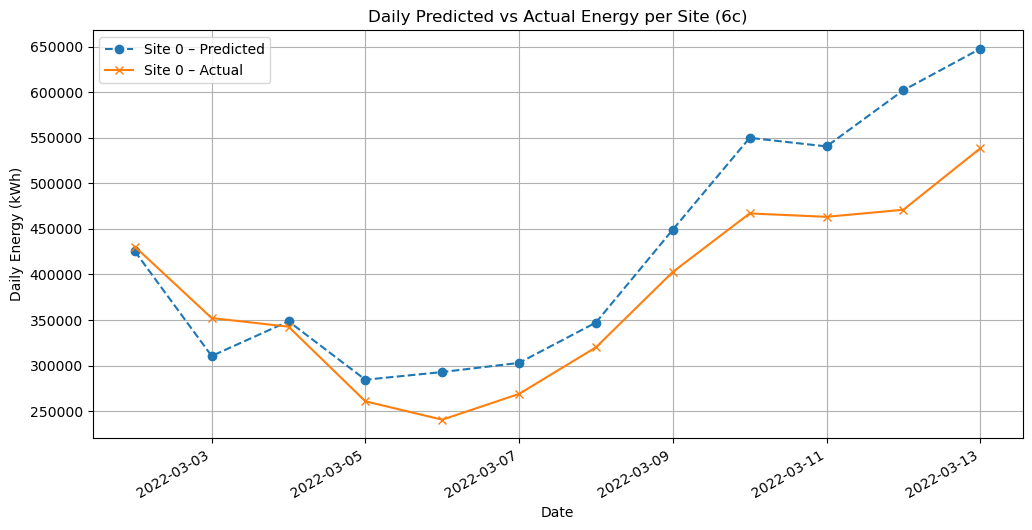

Heartbeat poll expired, leaving group


In [ ]:
running = True

# Interactive plotting
plt.ion()
fig, ax = plt.subplots(figsize=(12, 6))
records_daily = []
seen_keys = set()

print("Streaming 6c data from Kafka... (Ctrl+C to stop)\n")

while running:
    raw_msgs = consumer_daily.poll(timeout_ms=1000)
    for tp, msgs in raw_msgs.items():
        for msg in msgs:
            data = msg.value
            key = (data["site_id"], data["date"])
            if key not in seen_keys:
                records_daily.append(data)
                seen_keys.add(key)

    if not records_daily:
        continue

    df = pd.DataFrame(records_daily)
    df['date'] = pd.to_datetime(df['date'])

    ax.clear()
    for sid in df['site_id'].unique():
        sdf = df[df['site_id'] == sid].sort_values('date')

        ax.plot(sdf['date'], sdf['predicted_daily_energy'],
                label=f'Site {sid} – Predicted', marker='o', linestyle='--')

        ax.plot(sdf['date'], sdf['actual_daily_energy'],
                label=f'Site {sid} – Actual', marker='x', linestyle='-')

    ax.set_title("Daily Predicted vs Actual Energy per Site (6c)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily Energy (kWh)")
    ax.grid(True)
    ax.legend()
    fig.autofmt_xdate()
    plt.pause(2)

plt.ioff()
plt.show()

This interactive line chart visualizes daily predicted and actual energy consumption per site, based on real-time data streamed from Kafka. A line chart was chosen to effectively illustrate temporal patterns and facilitate direct comparison between predicted (o markers with dashed lines) and actual (x markers with solid lines) energy values.  
  
Each site's data is clearly distinguished using consistent line styles and markers, maintaining clarity even with overlapping series. The plot updates dynamically using `plt.ion()` and `plt.pause()`, while `ax.clear()` ensures a smooth refresh on each new Kafka batch. The visual is clean, time-focused, and optimized for monitoring predictive model accuracy over time.

### 3.	Plot a diagram to visualise the daily shortfall/excess energy in each site. The shortfall/excess energy is defined as the predicted total sum of energy in each site, minus the metered data (the value can be positive or negative, depending on the model and data quality).

Streaming daily energy data for shortfall/excess... (Ctrl+C to stop)



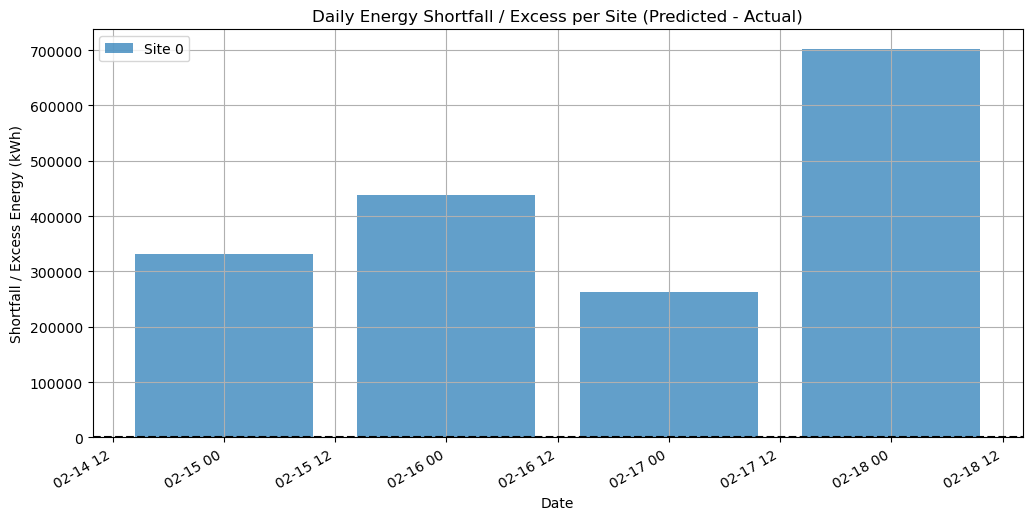

Heartbeat poll expired, leaving group


In [ ]:
# Interactive Plot Setup
plt.ion()
fig, ax = plt.subplots(figsize=(12, 6))
records_daily = []
seen_keys = set()

print("Streaming daily energy data for shortfall/excess... (Ctrl+C to stop)\n")

while running:
    raw_msgs = consumer_daily.poll(timeout_ms=1000)
    for tp, msgs in raw_msgs.items():
        for msg in msgs:
            data = msg.value
            key = (data["site_id"], data["date"])
            if key not in seen_keys:
                records_daily.append(data)
                seen_keys.add(key)

    if not records_daily:
        continue

    # Prepare DataFrame
    df = pd.DataFrame(records_daily)
    df['date'] = pd.to_datetime(df['date'])
    df['shortfall_or_excess'] = df['predicted_daily_energy'] - df['actual_daily_energy']

    # Plotting
    ax.clear()
    for sid in df['site_id'].unique():
        sdf = df[df['site_id'] == sid].sort_values('date')
        ax.bar(
            sdf['date'],
            sdf['shortfall_or_excess'],
            label=f"Site {sid}",
            alpha=0.7
        )

    ax.axhline(0, color='black', linestyle='--')
    ax.set_title("Daily Energy Shortfall / Excess per Site (Predicted - Actual)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Shortfall / Excess Energy (kWh)")
    ax.legend()
    ax.grid(True)
    fig.autofmt_xdate()
    plt.pause(2)

plt.ioff()
plt.show()

This real-time bar chart visualizes the daily energy shortfall or excess by calculating the difference between predicted and actual energy usage per site. A bar chart is used here instead of a line plot to clearly emphasize the magnitude and direction (positive or negative) of discrepancies, making it easy to spot over- or under-predictions.  
  
Each site's data is displayed with semi-transparent bars (alpha=0.7) for visual clarity when overlaps occur. A dashed horizontal line at zero serves as a baseline, quickly indicating whether predictions exceeded (positive bars) or fell short (negative bars) of actual usage. The chart is updated interactively using `plt.ion()` and `plt.pause()`, ensuring smooth live monitoring as new Kafka records arrive.